In [1]:
import sys
if sys.version_info[:2] != (3,11):
    raise Exception("Must be using Python 3.11. Deepchem is not compatible with newer versions of python. If on Colab switch to 2025.07 runtime version")

In [2]:
pip install rdkit deepchem numpy torch transformers scikit-learn statsmodels seaborn plotly umap-learn SALib xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78

In [3]:
import deepchem as dc
import numpy as np
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer='ECFP',
    splitter='scaffold' #Split the molecules into training/test, stratifying by their molecular structure
)

train_dataset, valid_dataset, test_dataset = datasets

#Identify which task is the NR-AR task
task_idx = tasks.index('NR-AR')

#Get the SMILE data from the data points (The molecular representation like "CCO")
def extract_smiles_and_labels(dataset, task_idx):
    y = dataset.y[:, task_idx]
    w = dataset.w[:, task_idx]

    #Remove molecules with a missing label...
    mask = w.flatten() > 0
    smiles = dataset.ids[mask].tolist()
    labels = y[mask]
    return smiles, labels

smiles_train, y_train = extract_smiles_and_labels(train_dataset, task_idx)
smiles_valid, y_valid = extract_smiles_and_labels(valid_dataset, task_idx)
smiles_test,  y_test  = extract_smiles_and_labels(test_dataset,  task_idx)

#For now combine the validation and train data
smiles_train_full = smiles_train + smiles_valid
y_train_full = np.concatenate([y_train, y_valid])

print(f"Train samples: {len(y_train_full)} (active molecules: {y_train_full.sum()})")
print(f"Test samples:  {len(y_test)} (active molecules: {y_test.sum()})")

Streaming output truncated to the last 5000 lines.
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:07:21] DEPRECATION WARNING: please use MorganGenerator
[18:0

Train samples: 6543 (active molecules: 281.0)
Test samples:  715 (active molecules: 27.0)


In [4]:
import torch
from transformers import AutoTokenizer, AutoModel
#Load ChemBERTa for embeddings
model_name = "DeepChem/ChemBERTa-77M-MTR"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(smiles):
    tokenized = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        input_ids = tokenized["input_ids"]
        attention_mask = tokenized["attention_mask"]
        outputs = model(input_ids,attention_mask)
        # Mean over token embeddings
        emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        return emb

def compute_embeddings(smiles_list):
    embeddings = []
    for smi in smiles_list:
        emb = get_embedding(smi)
        if emb is not None:
            embeddings.append(emb)
    return np.array(embeddings)

print("Computing train embeddings")
X_train = compute_embeddings(smiles_train_full)

print("Computing test embeddings")
X_test = compute_embeddings(smiles_test)
print("--- Embedding stats ---");
minimum_val = np.minimum(np.min(X_train), np.min(X_test))
maximum_val = np.maximum(np.max(X_train), np.max(X_test))
print(f"Embeddings: [{minimum_val}, {maximum_val}]")



tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Computing train embeddings


model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Computing test embeddings
--- Embedding stats ---
Embeddings: [-4.779587268829346, 4.238003253936768]


In [5]:
import pandas as pd
'''print("This will take a while!")
from sklearn.preprocessing import StandardScaler

def calculate_vif(X, thresh=10.0):
    X_scaled_df = pd.DataFrame(StandardScaler().fit_transform(X), columns=[f'feature{i}' for i in range(X.shape[1])])
    while True:
        #Compute the vif which takes very long
        vif = pd.DataFrame()
        vif['feature'] = X_scaled_df.columns
        vif['VIF'] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]
        max_vif = vif['VIF'].max()
        #If the vif is larger than 10 remove the column and repeat.
        if max_vif > thresh:
            drop_feature = vif.loc[vif['VIF'] == max_vif, 'feature'].values[0]
            print(f"Dropping {drop_feature} with VIF={max_vif}")
            X_scaled_df = X_scaled_df.drop(columns=[drop_feature])
        else:
            break
    return X_scaled_df, vif

X_clean, final_vif = calculate_vif(X_train)
print(final_vif)'''

#Precomputed list of enabled features with <10 VIF
#enabled_features = [0,2,10,12,15,18,19,20,21,26,29,30,36,38,39,43,44,47,48,50,51,52,54,56,62,63,67,68,69,74,77,78,80,84,87,89,96,98,106,110,111,114,115,118,119,120,123,124,125,130,132,133,138,139,142,145,148,152,153,158,160,162,163,168,171,172,175,180,183,184,185,188,198,199,201,205,209,211,213,216,218,219,227,233,236,238,243,244,253,257,260,265,266,270,272,276,283,285,293,294,302,306,307,310,315,320,322,324,326,327,330,331,333,338,339,340,341,345,353,354,359,360,361,362,366,371,372,374,376,381,383]
#X_train_final = X_train[:, enabled_features]
#X_test_final = X_test[:, enabled_features]
X_train_final = X_train
X_test_final = X_test
print("Features reduced.")

Features reduced.


Train accuracy: 0.9714198379948036
Test accuracy: 0.9706293706293706

=== Test Metrics ===
Accuracy: 0.9706293706293706
Precision: 0.875
Recall: 0.25925925925925924
F1 Score: 0.4
Confusion Matrix:
 [[687   1]
 [ 20   7]]


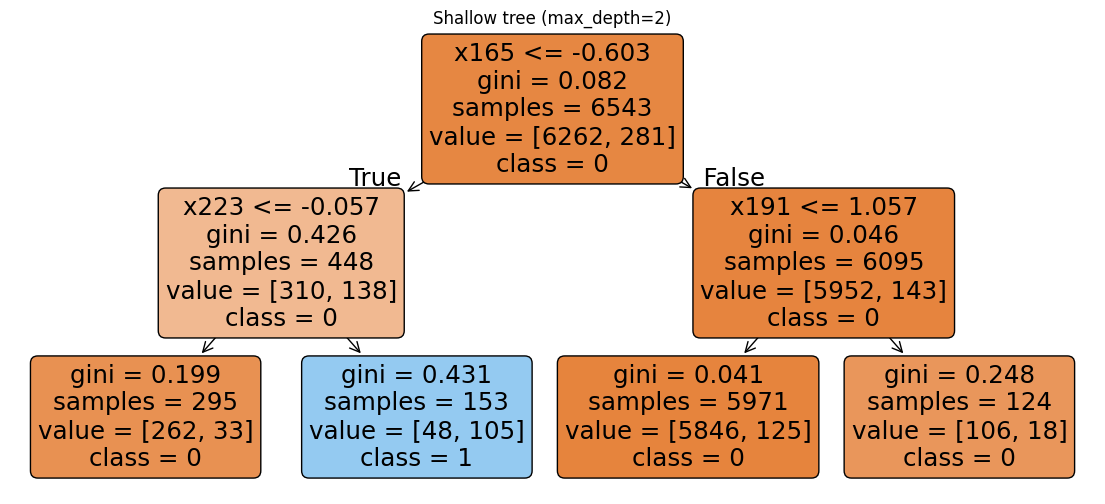

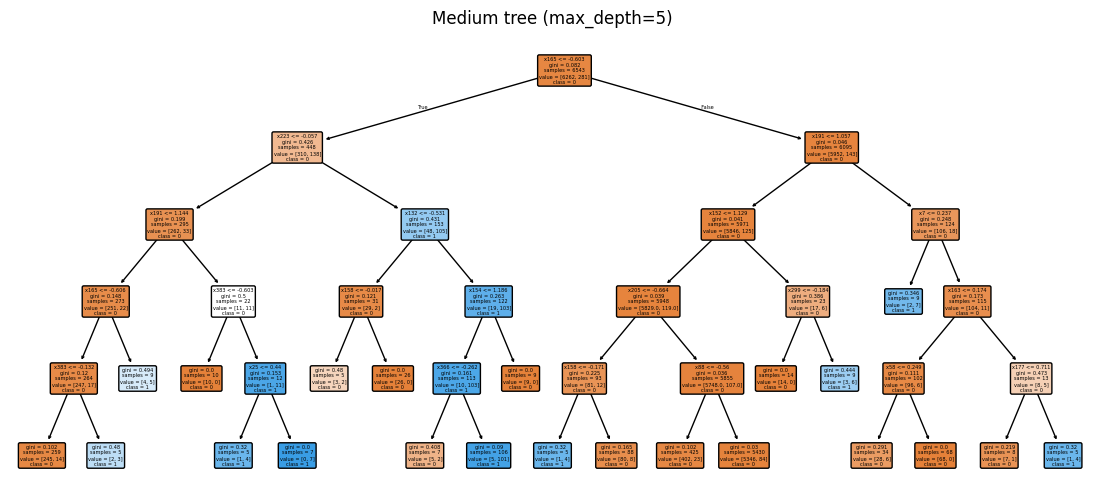

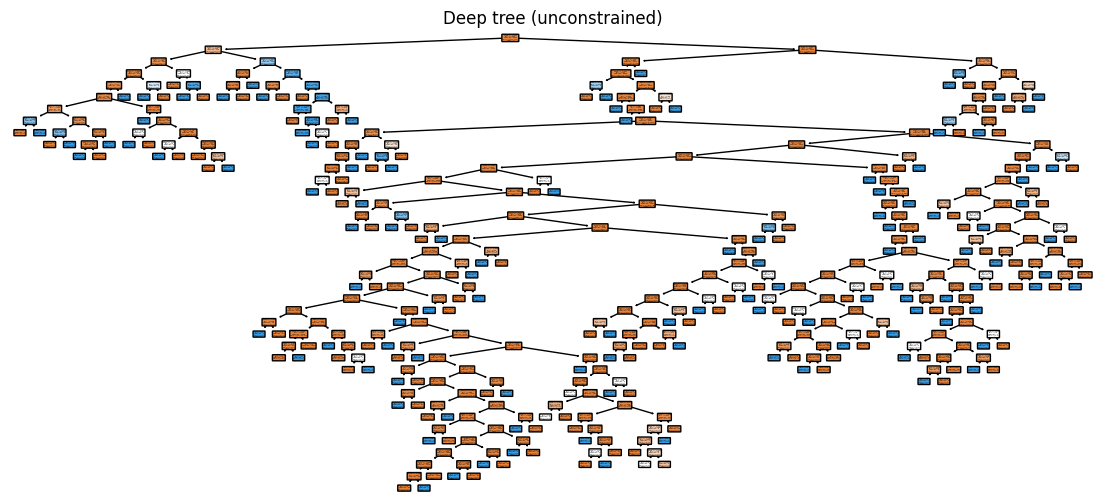

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train a basic decision tree
dt = DecisionTreeClassifier(
    criterion="gini",      # or "entropy"
    max_depth=5,        # unconstrained depth
    random_state=123,
    ccp_alpha = 0.002
)

dt.fit(X_train_final, y_train_full)

# Evaluate
train_pred = dt.predict(X_train_final)
test_pred = dt.predict(X_test_final)

print("Train accuracy:", accuracy_score(y_train_full, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("\n=== Test Metrics ===")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1 Score:", f1_score(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

settings = [
    {"max_depth": 2, "min_samples_leaf": 5, "title": "Shallow tree (max_depth=2)"},
    {"max_depth": 5, "min_samples_leaf": 5, "title": "Medium tree (max_depth=5)"},
    {"max_depth": None, "min_samples_leaf": 1, "title": "Deep tree (unconstrained)"}
]

for cfg in settings:
    model = DecisionTreeClassifier(
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        random_state=123
    )
    model.fit(X_train_final, y_train_full)

    plt.figure(figsize=(14, 6))
    plot_tree(
        model,
        filled=True,
        feature_names=[f"x{i}" for i in range(X_train_final.shape[1])],
        class_names=["0", "1"],
        rounded=True
    )
    plt.title(cfg["title"])
    plt.show()


### Task 1
1) A shallow tree only allows for few splits and has more coarse decision boundaries. A shallow tree is less likely to overfit because it doesn't end up "honing in" on specific data points which don't really accurately represent the underlying pattern that leads to accurate classification. However the shallow tree does not allow a high complexity for identifying complex relationships between features and classification.  
The medium depth tree allows for some sufficient complexity for identifying patterns but doesn't give the model so many degrees of freedom that it fails to generalize. In my hand tuning I found that a max depth of 4-5 was best for accuracy on the test data
The unlimited depth tree reaches a depth of nearly 40 and it has essentially set up perfect boundaries on training data to reach a perfect accuracy. However this generalizes very poorly to test data because it has gone beyond just identifying specific patterns and has memorized noise in training data so the randomness of test points does not match this noise and therefores fails to be classified accurately.

2) I used Morris sensitivity analysis. https://salib.readthedocs.io/en/latest/ Factorial Sampling Plans for Preliminary Computational Experiments -Max D. Morris. Basically it picks N random points from the sample space and then loops over N points, changing features OAT, through num_levels different values and then records data like how the change in a feature correlates to a change in the predicted classification. We see the following features identified:
x165: μ = -0.0078, μ* = 0.0078, σ = 0.0288, μ*_conf = 0.0101
x223: μ = -0.0028, μ* = 0.0028, σ = 0.0142, μ*_conf = 0.0055
x337: μ = 0.0011, μ* = 0.0011, σ = 0.0056, μ*_conf = 0.0023
This shows that the following increase the likelihood of inferring a 1: decrease x165, decrease x223, increase x337. u* conf indicates a confidence interval on our values. Overall the results make a lot of sense because when we look at the graph of the models above we see that x165 and x223 are the first 2 features used during the classification therefore they would have a significant impact on the classification.


       mu  mu_star  sigma  mu_star_conf
x0    0.0      0.0    0.0           0.0
x1    0.0      0.0    0.0           0.0
x2    0.0      0.0    0.0           0.0
x3    0.0      0.0    0.0           0.0
x4    0.0      0.0    0.0           0.0
...   ...      ...    ...           ...
x379  0.0      0.0    0.0           0.0
x380  0.0      0.0    0.0           0.0
x381  0.0      0.0    0.0           0.0
x382  0.0      0.0    0.0           0.0
x383  0.0      0.0    0.0           0.0

[384 rows x 4 columns]
Features with nonzero μ* values:
x165: μ = -0.0078, μ* = 0.0078, σ = 0.0288, μ*_conf = 0.0110
x223: μ = -0.0028, μ* = 0.0028, σ = 0.0142, μ*_conf = 0.0053
x337: μ = 0.0011, μ* = 0.0011, σ = 0.0056, μ*_conf = 0.0024


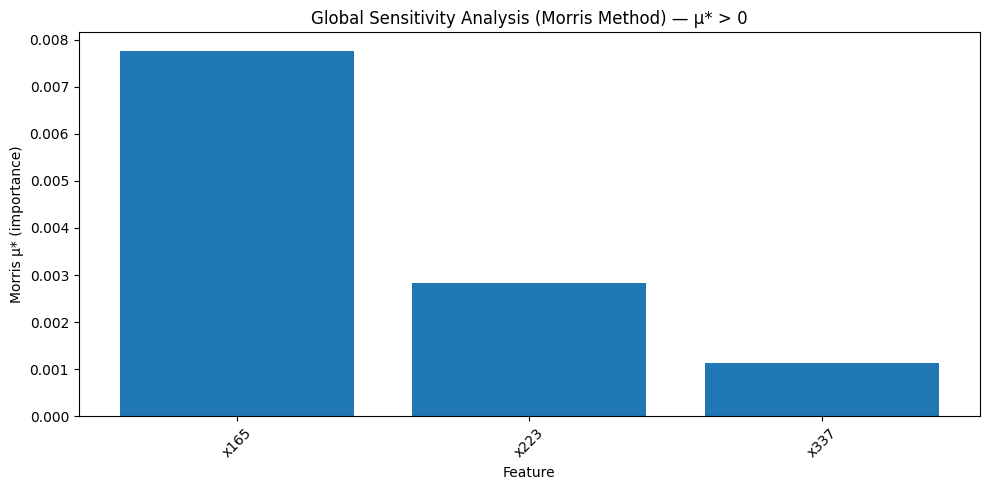

In [7]:
from SALib.sample import morris
from SALib.analyze import morris as morris_analyze
import matplotlib.pyplot as plt
import numpy as np

def model_predict(X):
    """Returns predicted probability of positive class."""
    return dt.predict_proba(X)[:, 1]

D = X_train_final.shape[1]

problem = {
    "num_vars": D,
    "names": [f"x{i}" for i in range(D)],
    "bounds": [
        [X_train_final[:, i].min(), X_train_final[:, i].max()]
        for i in range(D)
    ]
}

# Generate Morris samples
param_values = morris.sample(
    problem,
    N=100,
    num_levels=8,
    optimal_trajectories=25,
    seed=123
)

# Evaluate model
Y = model_predict(param_values)

# Perform Morris analysis
Si = morris_analyze.analyze(
    problem,
    param_values,
    Y,
    conf_level=0.95,
    print_to_console=True
)

# Convert to arrays for easy filtering
mu_star = np.array(Si["mu_star"])
feature_names = np.array(problem["names"])
mu = np.array(Si["mu"])  # direction
sigma = np.array(Si["sigma"])
mu_star_conf = np.array(Si["mu_star_conf"])

# Filter features with mu_star > 0
mask = mu_star > 0
filtered_mu_star = mu_star[mask]
filtered_features = feature_names[mask]
filtered_mu = mu[mask]
filtered_sigma = sigma[mask]
filtered_conf = mu_star_conf[mask]

# Print only features with nonzero μ*
print("Features with nonzero μ* values:")
for name, m, s, c, mst in zip(filtered_features, filtered_mu, filtered_sigma, filtered_conf, filtered_mu_star):
    print(f"{name}: μ = {m:.4f}, μ* = {mst:.4f}, σ = {s:.4f}, μ*_conf = {c:.4f}")

# Plot only features with mu_star > 0
plt.figure(figsize=(10, 5))
plt.bar(filtered_features, filtered_mu_star)
plt.ylabel("Morris μ* (importance)")
plt.xlabel("Feature")
plt.title("Global Sensitivity Analysis (Morris Method) — μ* > 0")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier
from itertools import combinations
from scipy.stats import ttest_rel

N_SPLITS = 5
RANDOM_STATE = 123

#1 Decision tree
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=123,
    ccp_alpha = 0.001
)


# 2.
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=25,
    learning_rate=0.2,
    subsample=0.9,
    colsample_bytree=0.5,
    random_state=123,
    scale_pos_weight = 96/4
)


# 3. Bagging classifier
base_model = DecisionTreeClassifier(
    max_depth=7
)
bagging_clf = BaggingClassifier(
    estimator=base_model,
    n_estimators=300,        # number of bootstrapped trees
    max_samples=0.9,         # fraction of training samples per tree
    max_features=0.4,        # fraction of features per tree
    bootstrap=True,
    random_state=123,
    n_jobs=-1
)

models = {
    "decisiontree": dt,
    "xgb": xgb_model,
    "bagging": bagging_clf
}

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = {
    model_name: {
        "accuracy": [],
        "precision": [],
        "f1": []
    }
    for model_name in models
}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train_full), 1):
    print(f"\nFold {fold_idx}/{N_SPLITS}")

    X_train, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_val, y_pred, average="weighted")

        results[model_name]["accuracy"].append(acc)
        results[model_name]["precision"].append(prec)
        results[model_name]["f1"].append(f1)

        if fold_idx == 1:
            cm = confusion_matrix(y_val, y_pred)
            print(f"\nConfusion Matrix ({model_name}, Fold 1):")
            print(cm)

print("\n=== Cross-Validation Results (Average Across Folds) ===")

for model_name, metrics in results.items():
    avg_acc = np.mean(metrics["accuracy"])
    avg_prec = np.mean(metrics["precision"])
    avg_f1 = np.mean(metrics["f1"])

    print(
        f"{model_name} -> "
        f"Accuracy: {avg_acc:.4f}, "
        f"Precision: {avg_prec:.4f}, "
        f"F1: {avg_f1:.4f}"
    )

for model_a, model_b in combinations(results.keys(), 2):
    f1_a = np.array(results[model_a]["f1"])
    f1_b = np.array(results[model_b]["f1"])

    t_stat, p_value = ttest_rel(f1_a, f1_b)

    mean_diff = np.mean(f1_a - f1_b)

    print(f"\nPaired t-test: {model_a} vs {model_b}")
    print(f"Mean F1 difference ({model_a} - {model_b}): {mean_diff:.6f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Result: Statistically significant difference")
    else:
        print("Result: No statistically significant difference")


Fold 1/5

Confusion Matrix (decisiontree, Fold 1):
[[1250    3]
 [  34   22]]

Confusion Matrix (xgb, Fold 1):
[[1250    3]
 [  27   29]]

Confusion Matrix (bagging, Fold 1):
[[1252    1]
 [  31   25]]

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5

=== Cross-Validation Results (Average Across Folds) ===
decisiontree -> Accuracy: 0.9678, Precision: 0.9635, F1: 0.9612
xgb -> Accuracy: 0.9728, Precision: 0.9702, F1: 0.9690
bagging -> Accuracy: 0.9722, Precision: 0.9708, F1: 0.9667

Paired t-test: decisiontree vs xgb
Mean F1 difference (decisiontree - xgb): -0.007707
t-statistic: -6.4369
p-value: 0.0030
Result: Statistically significant difference

Paired t-test: decisiontree vs bagging
Mean F1 difference (decisiontree - bagging): -0.005461
t-statistic: -4.8454
p-value: 0.0084
Result: Statistically significant difference

Paired t-test: xgb vs bagging
Mean F1 difference (xgb - bagging): 0.002245
t-statistic: 2.6621
p-value: 0.0563
Result: No statistically significant difference
